# Module 1 — Data Preprocessing
**Unit II — Pandas | IPL 2008–2019**

This module cleans the raw data and creates 4 output files used by all other modules:
- `data/clean/deliveries_clean.csv` — base ball-by-ball data
- `data/clean/legal_deliveries.csv` — only valid batting deliveries
- `data/clean/matches_clean.csv` — match-level data
- `data/derived/player_stats.csv` — batting stats per player
- `data/derived/bowler_stats.csv` — bowling stats per player

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')
from pathlib import Path


Libraries loaded successfully


In [2]:
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'deliveries.csv').exists() and (candidate / 'matches.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find project root containing deliveries.csv and matches.csv')

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT
CLEAN_DATA_DIR = PROJECT_ROOT / 'data' / 'clean'
DERIVED_DATA_DIR = PROJECT_ROOT / 'data' / 'derived'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

for path in (CLEAN_DATA_DIR, DERIVED_DATA_DIR, FIGURES_DIR):
    path.mkdir(parents=True, exist_ok=True)

print('Project root    ->', PROJECT_ROOT)
print('Clean data dir  ->', CLEAN_DATA_DIR)
print('Derived data dir->', DERIVED_DATA_DIR)
print('Figures dir     ->', FIGURES_DIR)


Project root    -> c:\Users\lakha\OneDrive\Desktop\dv_ha_cp
Clean data dir  -> c:\Users\lakha\OneDrive\Desktop\dv_ha_cp\data\clean
Derived data dir-> c:\Users\lakha\OneDrive\Desktop\dv_ha_cp\data\derived
Figures dir     -> c:\Users\lakha\OneDrive\Desktop\dv_ha_cp\outputs\figures


## Step 2 — Load Raw Data

In [3]:
deliveries = pd.read_csv(RAW_DATA_DIR / 'deliveries.csv')
matches    = pd.read_csv(RAW_DATA_DIR / 'matches.csv')

print('deliveries shape:', deliveries.shape)
print('matches shape   :', matches.shape)
print()
print('deliveries columns:', list(deliveries.columns))
print()
print('matches columns:', list(matches.columns))

deliveries shape: (179078, 21)
matches shape   : (756, 18)

deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']

matches columns: ['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


## Step 3 — Preview Raw Data

In [4]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN


In [5]:
matches.head(3)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN


## Step 4 — Inspect Data Types and Nulls

In [6]:
print('=== DELIVERIES — DATA TYPES ===')
print(deliveries.dtypes)
print()
print('=== DELIVERIES — NULL COUNTS ===')
print(deliveries.isnull().sum())
print() 
print('NOTE: player_dismissed, dismissal_kind, fielder are null when no wicket falls — this is NORMAL.')

=== DELIVERIES — DATA TYPES ===
match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batsman             object
non_striker         object
bowler              object
is_super_over        int64
wide_runs            int64
bye_runs             int64
legbye_runs          int64
noball_runs          int64
penalty_runs         int64
batsman_runs         int64
extra_runs           int64
total_runs           int64
player_dismissed    object
dismissal_kind      object
fielder             object
dtype: object

=== DELIVERIES — NULL COUNTS ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
no

In [7]:
print('=== MATCHES — DATA TYPES ===')
print(matches.dtypes)
print()
print('=== MATCHES — NULL COUNTS ===')
print(matches.isnull().sum())
print() 
print('NOTE: umpire3 is almost entirely null — will be dropped.')
print('NOTE: winner is null for no-result matches (rain etc.) — will be removed.')

=== MATCHES — DATA TYPES ===
id                  int64
season              int64
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
result             object
dl_applied          int64
winner             object
win_by_runs         int64
win_by_wickets      int64
player_of_match    object
venue              object
umpire1            object
umpire2            object
umpire3            object
dtype: object

=== MATCHES — NULL COUNTS ===
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

NOTE: umpire3 is almost entire

## Step 5 — Validate Data Quality

In [8]:
# Check for duplicate rows
dup_deliveries = deliveries.duplicated().sum()
dup_matches    = matches.duplicated().sum()
print('Duplicate rows in deliveries:', dup_deliveries)
print('Duplicate rows in matches   :', dup_matches)

Duplicate rows in deliveries: 23
Duplicate rows in matches   : 0


In [9]:
# Check over and ball ranges
print('Over range :', deliveries['over'].min(), 'to', deliveries['over'].max())
print('Ball range :', deliveries['ball'].min(), 'to', deliveries['ball'].max())
print() 
print('NOTE: Ball values > 6 are normal — they happen when a wide or no-ball earlier in')
print('      the over pushes the sequential ball counter above 6. Not a data error.')
print() 
print('Overs outside 1-20:', deliveries[(deliveries['over'] < 1) | (deliveries['over'] > 20)].shape[0])

Over range : 1 to 20
Ball range : 1 to 9

NOTE: Ball values > 6 are normal — they happen when a wide or no-ball earlier in
      the over pushes the sequential ball counter above 6. Not a data error.

Overs outside 1-20: 0


In [10]:
# Check total_runs range — flag anything negative or unusually high
print('Total runs range:', deliveries['total_runs'].min(), 'to', deliveries['total_runs'].max())
print('Rows with total_runs > 7:', deliveries[deliveries['total_runs'] > 7].shape[0])
print('Rows with total_runs < 0:', deliveries[deliveries['total_runs'] < 0].shape[0])
print() 
print('NOTE: Runs > 6 are valid (e.g. overthrows + no-ball). No removal needed.')

Total runs range: 0 to 10
Rows with total_runs > 7: 80
Rows with total_runs < 0: 0

NOTE: Runs > 6 are valid (e.g. overthrows + no-ball). No removal needed.


In [11]:
# Check dismissal kinds
print('All dismissal types in dataset:')
print(deliveries['dismissal_kind'].value_counts())
print()
print('NOTE: run out and retired hurt do NOT count as bowler wickets.')

All dismissal types in dataset:
dismissal_kind
caught                   5348
bowled                   1581
run out                   852
lbw                       540
stumped                   278
caught and bowled         211
retired hurt               12
hit wicket                 10
obstructing the field       2
Name: count, dtype: int64

NOTE: run out and retired hurt do NOT count as bowler wickets.


## Step 6 — Clean Matches: Remove No-Result Games and Useless Column

In [12]:
# Drop umpire3 — 637 of 756 values are null, not useful for analysis
matches = matches.drop(columns=['umpire3'])

# Remove no-result matches (rain-affected games where winner is null)
matches_clean = matches[matches['result'] != 'no result'].copy()
matches_clean = matches_clean.reset_index(drop=True)

print('Original matches     :', len(matches))
print('After removing no-result:', len(matches_clean))
print('Seasons present:', sorted(matches_clean['season'].unique()))

Original matches     : 756
After removing no-result: 752
Seasons present: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


## Step 7 — Standardize Team Names (Franchise Rebrands)

In [13]:
# IPL franchises changed names over the years.
# We map old names to their current/standard name for consistent analysis.
team_map = {
    'Delhi Daredevils'       : 'Delhi Capitals',
    'Deccan Chargers'        : 'Sunrisers Hyderabad',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants',
    'Kings XI Punjab'        : 'Punjab Kings',
}
# Note: Pune Warriors, Kochi Tuskers Kerala, Gujarat Lions are
# defunct franchises — they are kept as-is (no current successor).

# Apply to deliveries
deliveries['batting_team'] = deliveries['batting_team'].replace(team_map)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_map)

# Apply to matches
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches_clean[col] = matches_clean[col].replace(team_map)

print('Unique teams after normalization:')
print(sorted(deliveries['batting_team'].unique()))
print()
print('Total unique franchises:', deliveries['batting_team'].nunique())

Unique teams after normalization:
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

Total unique franchises: 12


## Step 8 — Remove Duplicate Rows

In [14]:
# The raw deliveries dataset contains 23 genuinely duplicated rows
# (same match_id, over, ball, batsman, runs recorded twice — data entry error)
before = len(deliveries)
deliveries = deliveries.drop_duplicates().reset_index(drop=True)
after = len(deliveries)

print('Rows before deduplication:', before)
print('Rows after deduplication :', after)
print('Duplicate rows removed   :', before - after)

Rows before deduplication: 179078
Rows after deduplication : 179055
Duplicate rows removed   : 23


## Step 9 — Remove Super Overs

In [15]:
print('Super over entries in raw data:', deliveries['is_super_over'].value_counts().to_dict())

# Super overs are tie-breaker overs — different rules, kept separate
deliveries = deliveries[deliveries['is_super_over'] == 0].copy()
deliveries = deliveries.reset_index(drop=True)

print('Rows after removing super overs:', len(deliveries))

Super over entries in raw data: {0: 178974, 1: 81}
Rows after removing super overs: 178974


## Step 10 — Add Season Column to Deliveries

In [16]:
# Merge season from matches into deliveries
season_map = matches[['id', 'season']].rename(columns={'id': 'match_id'})
deliveries = deliveries.merge(season_map, on='match_id', how='left')

print('Seasons now in deliveries:', sorted(deliveries['season'].unique()))

Seasons now in deliveries: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


## Step 11 — Add Match Phase Column

In [17]:
# Standard T20 phase classification
# Powerplay: Overs 1-6  (fielding restrictions apply)
# Middle:    Overs 7-15 (consolidation phase)
# Death:     Overs 16-20 (finishing phase)

def get_phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

deliveries['phase'] = deliveries['over'].apply(get_phase)

print('Phase distribution (all deliveries):')
print(deliveries['phase'].value_counts())

Phase distribution (all deliveries):
phase
Middle       82106
Powerplay    56470
Death        40398
Name: count, dtype: int64


## Step 12 — Add Helper Columns (Dot Ball, Boundary)

In [18]:
# is_dot_ball: no runs at all on that delivery
deliveries['is_dot_ball'] = (deliveries['total_runs'] == 0).astype(int)

# is_boundary: batsman hit a 4 or 6 (not extras)
deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4, 6]).astype(int)

print('Dot ball column added. Total dot balls:', deliveries['is_dot_ball'].sum())
print('Boundary column added. Total boundaries:', deliveries['is_boundary'].sum())

Dot ball column added. Total dot balls: 62976
Boundary column added. Total boundaries: 28535


## Step 13 — Create Legal Deliveries Dataset

**What is a legal delivery?**
A delivery where the batsman actually faces the ball — wides are excluded because the batsman cannot play them.
No-balls ARE included here because the batsman does face a no-ball and any runs scored count toward their stats.
This is the correct cricket definition.

In [19]:
# Legal = not a wide (batsman faces the ball)
# No-balls are INCLUDED — batsman does face them and runs count
legal = deliveries[deliveries['wide_runs'] == 0].copy()
legal = legal.reset_index(drop=True)

print('Total deliveries (incl. extras):', len(deliveries))
print('Legal deliveries (excl. wides) :', len(legal))
print('Wide deliveries removed        :', len(deliveries) - len(legal))

Total deliveries (incl. extras): 178974
Legal deliveries (excl. wides) : 173571
Wide deliveries removed        : 5403


## Step 14 — Build Batting Stats (player_stats)

**Important corrections from standard mistakes:**
- Strike rate uses only legal balls faced (excludes wides — already handled by using `legal`)
- Batting average = runs / dismissals (NOT runs / innings)
- Dismissals count only: bowled, caught, lbw, stumped, caught and bowled, hit wicket
- Run outs are NOT included — that is a fielding action, not a bowling/batting contest

In [20]:
# Step A: Count runs and balls from legal deliveries
batting_base = legal.groupby('batsman').agg(
    total_runs  = ('batsman_runs', 'sum'),
    total_balls = ('ball', 'count'),
    fours       = ('batsman_runs', lambda x: (x == 4).sum()),
    sixes       = ('batsman_runs', lambda x: (x == 6).sum()),
    innings     = ('match_id', 'nunique')
).reset_index()

print('Base batting stats shape:', batting_base.shape)
batting_base.head(3)

Base batting stats shape: (516, 6)


,batsman,total_runs,total_balls,fours,sixes,innings
0,A Ashish Reddy,280,193,16,15,23
1,A Chandila,4,7,0,0,2
2,A Chopra,53,71,7,0,6


In [21]:
# Step B: Count VALID dismissals only (for correct batting average)
# run out, retired hurt, obstructing the field = NOT bowler's wicket,
# but they DO end a batsman's innings. For batting average:
# traditional cricket average = runs / times dismissed (all dismissals)

valid_dismissal_kinds = [
    'bowled',
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket',
    'run out',
    'obstructing the field'
]
# Note: 'retired hurt' is NOT a dismissal — batsman returns later

dismissed_rows = deliveries[deliveries['dismissal_kind'].isin(valid_dismissal_kinds)]
dismissal_counts = dismissed_rows.groupby('batsman').size().reset_index(name='dismissals')

print('Players with at least 1 dismissal:', len(dismissal_counts))

Players with at least 1 dismissal: 482


In [22]:
# Step C: Merge dismissals into batting stats
player_stats = batting_base.merge(dismissal_counts, on='batsman', how='left')

# Players with 0 dismissals (always not out) — set to 1 to avoid divide-by-zero
player_stats['dismissals'] = player_stats['dismissals'].fillna(1)

# Step D: Calculate metrics
# Strike rate = (runs / balls faced) * 100
player_stats['strike_rate'] = ((player_stats['total_runs'] / player_stats['total_balls']) * 100).round(1)

# Average = runs / times dismissed (correct cricket definition)
player_stats['average'] = (player_stats['total_runs'] / player_stats['dismissals']).round(1)

# Step E: Filter — minimum 200 legal balls faced (removes one-match wonders)
player_stats = player_stats[player_stats['total_balls'] >= 200].reset_index(drop=True)

print('Player stats table shape:', player_stats.shape)
print()
print('Top 5 by runs:')
print(player_stats.nlargest(5, 'total_runs')[['batsman', 'total_runs', 'total_balls', 'dismissals', 'strike_rate', 'average']].to_string())

Player stats table shape: (152, 9)

Top 5 by runs:
       batsman  total_runs  total_balls  dismissals  strike_rate  average
143    V Kohli        5421         4112       152.0        131.8     35.7
125   SK Raina        5382         3914       160.0        137.5     33.6
112  RG Sharma        4902         3744       162.0        130.9     30.3
28   DA Warner        4722         3305       113.0        142.9     41.8
118   S Dhawan        4604         3670       136.0        125.4     33.9


In [23]:
# Step F: Classify player type using median thresholds (no ML — pure logic)
sr_threshold  = player_stats['strike_rate'].median()
avg_threshold = player_stats['average'].median()

print('Strike Rate median threshold :', sr_threshold)
print('Average median threshold     :', avg_threshold)
print()

player_types = []

for i in range(len(player_stats)):
    high_sr  = player_stats.loc[i, 'strike_rate'] >= sr_threshold
    high_avg = player_stats.loc[i, 'average']     >= avg_threshold

    if high_sr and high_avg:
        player_types.append('Match Winner')
    elif high_sr and not high_avg:
        player_types.append('Aggressive')
    elif high_avg and not high_sr:
        player_types.append('Anchor')
    else:
        player_types.append('Support')

player_stats['player_type'] = player_types

print('Player type distribution:')
print(player_stats['player_type'].value_counts())

Strike Rate median threshold : 127.35
Average median threshold     : 25.1

Player type distribution:
player_type
Support         51
Match Winner    51
Anchor          25
Aggressive      25
Name: count, dtype: int64


## Step 15 — Build Bowling Stats (bowler_stats)

**Important corrections:**
- Economy rate uses legal deliveries (no wides — already in `legal` dataset)
- Wickets = only dismissals the BOWLER is credited for (excludes run outs, retired hurt)
- Run outs happen by fielder action — the bowler gets no credit

In [24]:
# Step A: Runs conceded and balls bowled from legal deliveries
# Note: total_runs here includes extras like leg byes which bowler concedes
bowling_base = legal.groupby('bowler').agg(
    runs_conceded = ('total_runs', 'sum'),
    balls         = ('ball', 'count'),
    matches       = ('match_id', 'nunique')
).reset_index()

print('Base bowling stats shape:', bowling_base.shape)

Base bowling stats shape: (405, 4)


In [25]:
# Step B: Count BOWLER wickets only
# run out, retired hurt, obstructing the field = NOT credited to bowler
bowler_wicket_kinds = [
    'bowled',
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket'
]

wicket_rows   = legal[legal['dismissal_kind'].isin(bowler_wicket_kinds)]
wicket_counts = wicket_rows.groupby('bowler').size().reset_index(name='wickets')

print('Bowlers with at least 1 wicket:', len(wicket_counts))

Bowlers with at least 1 wicket: 348


In [26]:
# Step C: Merge and calculate
bowler_stats = bowling_base.merge(wicket_counts, on='bowler', how='left')
bowler_stats['wickets'] = bowler_stats['wickets'].fillna(0).astype(int)

# Economy = runs conceded per over (6 balls)
bowler_stats['economy'] = ((bowler_stats['runs_conceded'] / bowler_stats['balls']) * 6).round(2)

# Overs bowled (for reference)
bowler_stats['overs'] = (bowler_stats['balls'] / 6).round(1)

# Step D: Filter — minimum 120 legal balls (~20 overs bowled)
bowler_stats = bowler_stats[bowler_stats['balls'] >= 120].reset_index(drop=True)

print('Bowler stats table shape:', bowler_stats.shape)
print()
print('Top 5 wicket takers:')
print(bowler_stats.nlargest(5, 'wickets')[['bowler', 'wickets', 'economy', 'overs', 'matches']].to_string())

Bowler stats table shape: (240, 7)

Top 5 wicket takers:
              bowler  wickets  economy  overs  matches
204       SL Malinga      170     7.05  474.2      122
3           A Mishra      156     7.28  520.3      147
156        PP Chawla      149     7.85  521.0      156
55          DJ Bravo      147     8.28  432.0      131
75   Harbhajan Singh      146     7.01  562.8      157


## Step 16 — Final Shape Check and Summary

In [27]:
print('=' * 55)
print('MODULE 1 — PREPROCESSING COMPLETE')
print('=' * 55)
print()
print(f'deliveries (cleaned)   : {deliveries.shape}')
print(f'legal deliveries       : {legal.shape}')
print(f'matches (cleaned)      : {matches_clean.shape}')
print(f'player_stats           : {player_stats.shape}')
print(f'bowler_stats           : {bowler_stats.shape}')
print()
print('Seasons covered:', sorted(deliveries['season'].unique()))
print('Teams in dataset:', deliveries['batting_team'].nunique())
print()
print('Columns added to deliveries:', ['season', 'phase', 'is_dot_ball', 'is_boundary'])

MODULE 1 — PREPROCESSING COMPLETE

deliveries (cleaned)   : (178974, 25)
legal deliveries       : (173571, 25)
matches (cleaned)      : (752, 17)
player_stats           : (152, 10)
bowler_stats           : (240, 7)

Seasons covered: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Teams in dataset: 12

Columns added to deliveries: ['season', 'phase', 'is_dot_ball', 'is_boundary']


In [28]:
# Quick sanity checks
print('=== SANITY CHECKS ===')
print()

# 1. No overs outside valid range
bad_overs = deliveries[(deliveries['over'] < 1) | (deliveries['over'] > 20)].shape[0]
print('Rows with invalid over (outside 1-20):', bad_overs)

# 2. No negative runs
neg_runs = deliveries[deliveries['total_runs'] < 0].shape[0]
print('Rows with negative total_runs:', neg_runs)

# 3. No duplicates
dups = deliveries.duplicated().sum()
print('Duplicate rows in cleaned deliveries:', dups)

# 4. Phase column covers all rows
missing_phase = deliveries['phase'].isnull().sum()
print('Rows missing phase value:', missing_phase)

# 5. Season column fully merged
missing_season = deliveries['season'].isnull().sum()
print('Rows missing season value:', missing_season)

print()
print('All checks passed if all values above are 0.')

=== SANITY CHECKS ===

Rows with invalid over (outside 1-20): 0
Rows with negative total_runs: 0
Duplicate rows in cleaned deliveries: 0
Rows missing phase value: 0
Rows missing season value: 0

All checks passed if all values above are 0.


## Step 17 — Data Quality Metrics (Raw vs Cleaned)

In [29]:
import matplotlib.pyplot as plt

# Load raw data fresh for comparison
raw_deliveries = pd.read_csv(RAW_DATA_DIR / 'deliveries.csv')

# Completeness: % of non-null values
def get_completeness(df):
    total_cells = df.shape[0] * df.shape[1]
    null_cells  = df.isnull().sum().sum()
    return round((1 - null_cells / total_cells) * 100, 2)

# Validity: % of rows where total_runs is in valid range (0-7 is reasonable for IPL)
def get_validity(df):
    invalid = df[(df['total_runs'] < 0) | (df['total_runs'] > 7)].shape[0]
    return round((1 - invalid / len(df)) * 100, 2)

# Uniqueness: % of non-duplicate rows
def get_uniqueness(df):
    dups = df.duplicated().sum()
    return round((1 - dups / len(df)) * 100, 2)

raw_c  = get_completeness(raw_deliveries)
raw_v  = get_validity(raw_deliveries)
raw_u  = get_uniqueness(raw_deliveries)
raw_o  = round((raw_c + raw_v + raw_u) / 3, 2)

clean_c = get_completeness(deliveries)
clean_v = get_validity(deliveries)
clean_u = get_uniqueness(deliveries)
clean_o = round((clean_c + clean_v + clean_u) / 3, 2)

print('                  Raw    Cleaned')
print(f'Completeness : {raw_c}%  {clean_c}%')
print(f'Validity     : {raw_v}%  {clean_v}%')
print(f'Uniqueness   : {raw_u}%  {clean_u}%')
print(f'Overall      : {raw_o}%  {clean_o}%')

                  Raw    Cleaned
Completeness : 86.36%  88.54%
Validity     : 99.96%  99.96%
Uniqueness   : 99.99%  100.0%
Overall      : 95.44%  96.17%


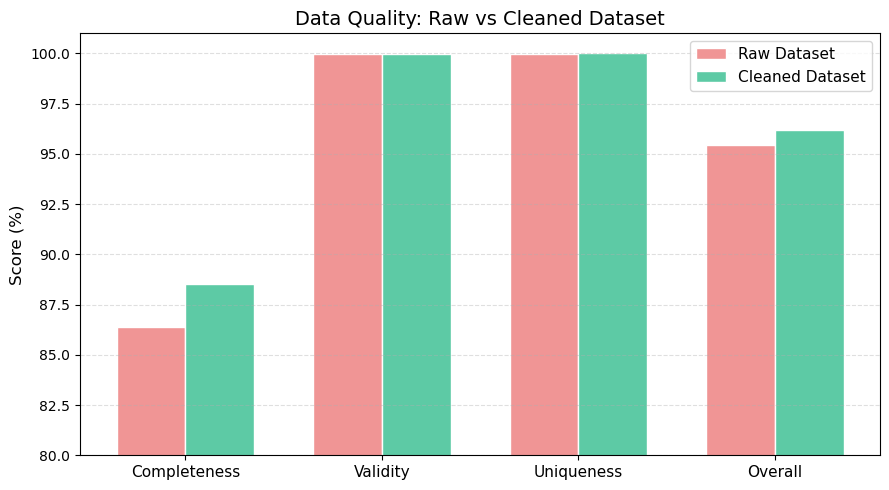

In [30]:
# Chart: Raw vs Cleaned Data Quality
metrics      = ['Completeness', 'Validity', 'Uniqueness', 'Overall']
raw_scores   = [raw_c, raw_v, raw_u, raw_o]
clean_scores = [clean_c, clean_v, clean_u, clean_o]

x     = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], raw_scores,   width, label='Raw Dataset',     color='#F09595', edgecolor='white')
ax.bar([i + width/2 for i in x], clean_scores, width, label='Cleaned Dataset', color='#5DCAA5', edgecolor='white')

ax.set_ylim(80, 101)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Data Quality: Raw vs Cleaned Dataset', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart0a_data_quality.png', dpi=150)
plt.show()

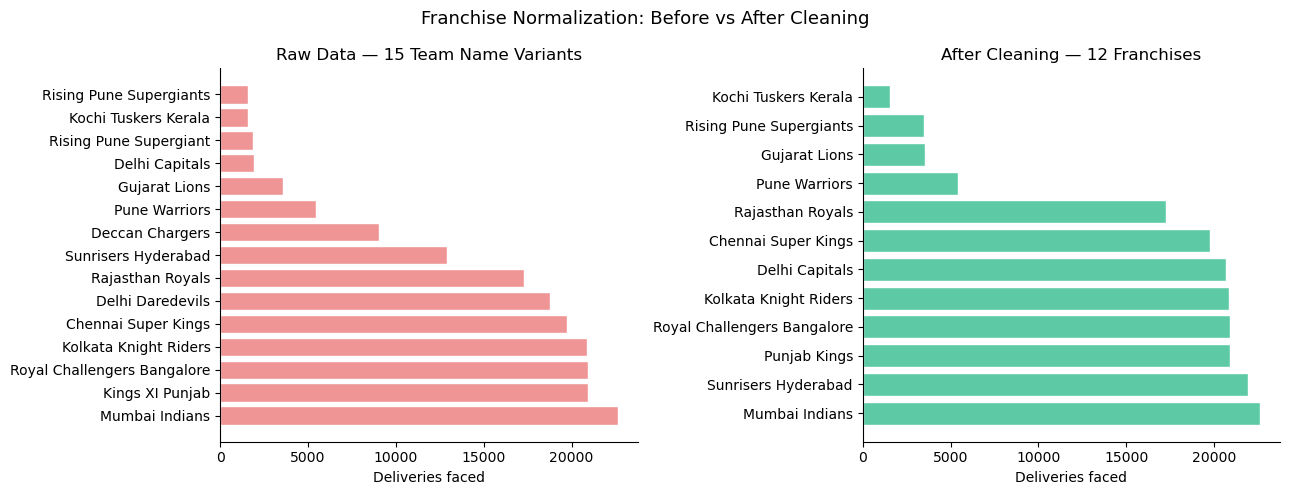

In [31]:
# Chart: Franchise normalization — before vs after
raw_team_counts   = raw_deliveries['batting_team'].value_counts()
clean_team_counts = deliveries['batting_team'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(raw_team_counts.index, raw_team_counts.values, color='#F09595', edgecolor='white')
axes[0].set_title(f'Raw Data — {len(raw_team_counts)} Team Name Variants', fontsize=12)
axes[0].set_xlabel('Deliveries faced')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].barh(clean_team_counts.index, clean_team_counts.values, color='#5DCAA5', edgecolor='white')
axes[1].set_title(f'After Cleaning — {len(clean_team_counts)} Franchises', fontsize=12)
axes[1].set_xlabel('Deliveries faced')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Franchise Normalization: Before vs After Cleaning', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart0b_team_normalization.png', dpi=150)
plt.show()

## Step 18 — Export All Clean Files

In [32]:
deliveries.to_csv(CLEAN_DATA_DIR / 'deliveries_clean.csv',   index=False)
legal.to_csv(CLEAN_DATA_DIR / 'legal_deliveries.csv',        index=False)
matches_clean.to_csv(CLEAN_DATA_DIR / 'matches_clean.csv',   index=False)
player_stats.to_csv(DERIVED_DATA_DIR / 'player_stats.csv',     index=False)
bowler_stats.to_csv(DERIVED_DATA_DIR / 'bowler_stats.csv',     index=False)

print('Files saved:')
print('  data/clean/deliveries_clean.csv  — cleaned ball-by-ball data (all modules)')
print('  data/clean/legal_deliveries.csv  — wides removed, for batting & bowling stats')
print('  data/clean/matches_clean.csv     — match-level data (Module 4)')
print('  data/derived/player_stats.csv      — batting stats with correct average & SR (Module 2)')
print('  data/derived/bowler_stats.csv      — bowling stats with correct wickets (Module 3)')

Files saved:
  data/clean/deliveries_clean.csv  — cleaned ball-by-ball data (all modules)
  data/clean/legal_deliveries.csv  — wides removed, for batting & bowling stats
  data/clean/matches_clean.csv     — match-level data (Module 4)
  data/derived/player_stats.csv      — batting stats with correct average & SR (Module 2)
  data/derived/bowler_stats.csv      — bowling stats with correct wickets (Module 3)
